In [81]:
%load_ext autoreload
%autoreload 2

import pathlib
import numpy as np
import matplotlib.pyplot as plt

from rl_task_active_sensing import ActiveSensingTaskRL
from teensy.fake_teensy import FakeTeensy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [82]:
config_name = pathlib.Path("task_config.json")
current_dir = pathlib.Path().parent
config_path = current_dir.joinpath(config_name)  # default class constructor input
print(config_path)

task_config.json


In [83]:
task = ActiveSensingTaskRL(
    teensy=FakeTeensy(),
    monitor=None,
    write_video=False,
    fps=60.0,
    session_label=["ar_discrim"],
    epochs=[250],
    epoch_labels=["dual_teardrop"],
    config_file_path=config_path,
    reward_size=100,
    cropped_image=[0, 530, 0, 510],
    unity_arena_size=[-9, 9, -10, -2],
    r_report_box=[5, 10, -4, -2],
    l_report_box=[-10, -5, -4, -2],
    start_box=[-4, 4, -9, -5, 90],
    rotate_camera=90.0,
    prob_obj_on_left=0.5,
    prob_block_coherence=0.5,
    mouse_report_delay=0.0,
    slit_size=[4.0, 10.0, 2],
    slit_depth=0.2,
    target_selection=6.0,
    distractor_selection=4.0,
    occlusion_type=0.0,
    camera_type=1.0,
    target_spread=4.0,
    target_rotation=0,
    target_size=2.0,
    target_height=3.0,
    block_length=1.0,
    start_box_delay=0.25,
    velocity_threshold=10.0,
    distractor=1.0,
    grey_screen_active=0.0,
    target_distance=3.0,
    use_dlc=False,
)

In [84]:
task.start()
obs, info = task.reset()

[DEBUG] Agent information
[DEBUG]   * Action space : Continuous: 4, Discrete: ()
[DEUBG]   * Observation space : [ObservationSpec(shape=(3, 1024, 2048), dimension_property=(<DimensionProperty.NONE: 1>, <DimensionProperty.TRANSLATIONAL_EQUIVARIANCE: 2>, <DimensionProperty.TRANSLATIONAL_EQUIVARIANCE: 2>), observation_type=<ObservationType.DEFAULT: 0>, name='Eyes'), ObservationSpec(shape=(13,), dimension_property=(<DimensionProperty.NONE: 1>,), observation_type=<ObservationType.DEFAULT: 0>, name='VectorSensor_size13')]


In [85]:
task.vis_obs_shape

(3, 1024, 2048)

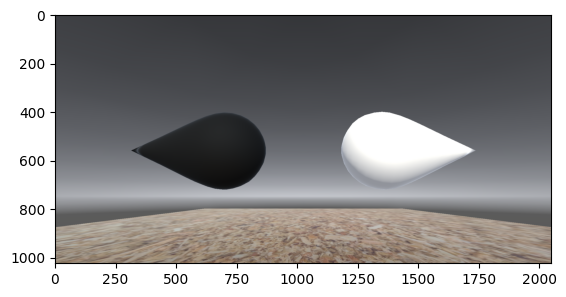

In [86]:
plt.imshow(np.transpose(obs[0], (1,2,0)))
plt.show()

In [88]:
observation, reward, terminated, truncated, info = task.loop(np.array([1,1]))

[DEBUG] Action received : [1 1]
[DEBUG]   * State before step : [  0.    -8.     0.     1.     0.     0.     0.     0.     0.   400.78
   0.     0.     0.  ]
[DEBUG]   * Transformed action : (0.0, 1.0, 1)
[DEBUG]   * State after step : [ 0.  -7.3  5.4  1.   0.   0.   0.   0.   0.  35.   0.   0.   0. ]


In [89]:
task.stop()

In [90]:
import pickle

with open("rl_task_data.pkl", "rb") as f:
    data_dict = pickle.load(f)

In [91]:
data_dict

{'start_time': 1754723081.423527,
 'episode': array([1, 1]),
 'step': array([1, 2]),
 'step_time': array([25.83879685, 44.70722389]),
 'state': array([[0.0, -7.300000190734863, 5.399997711181641, 1.0, 0.0, 0.0, 0.0,
         0.0, 0.0, 35.000003814697266, 0.0, 0.0, 0.0]], dtype=object),
 'action': array([[0., 1., 1., 0.]], dtype=float32),
 'reward': array([0.], dtype=float32),
 'terminal': array([False]),
 'session_label': ['ar_discrim'],
 'dlc_read_time': array([], dtype=float64),
 'dlc_x': array([], dtype=float64),
 'dlc_y': array([], dtype=float64),
 'dlc_heading': array([], dtype=float64),
 'block_labels': array(['dual_teardrop', 'dual_teardrop'], dtype='<U13'),
 'slit_size': array([10.,  4.]),
 'trial_slit_depth': array([0.2, 0.2]),
 'r_report_box': array([ 5, 10, -4, -2]),
 'l_report_box': array([-10,  -5,  -4,  -2]),
 'start_box': array([-4,  4, -9, -5, 90]),
 'cropped_image': array([  0, 530,   0, 510]),
 'unity_arena_size': array([ -9,   9, -10,  -2]),
 'camera_rotation': array

In [ ]:
from gymnasium.utils.env_checker import check_env

from rl_task_gym_wrapper import MouseTaskToGymWrapper

env = MouseTaskToGymWrapper(env_path=None)
check_env(env, skip_render_check=True)
env.close()

[DEBUG] Agent information
[DEBUG]   * Action space : Continuous: 4, Discrete: ()
[DEUBG]   * Observation space : [ObservationSpec(shape=(3, 1024, 2048), dimension_property=(<DimensionProperty.NONE: 1>, <DimensionProperty.TRANSLATIONAL_EQUIVARIANCE: 2>, <DimensionProperty.TRANSLATIONAL_EQUIVARIANCE: 2>), observation_type=<ObservationType.DEFAULT: 0>, name='Eyes'), ObservationSpec(shape=(13,), dimension_property=(<DimensionProperty.NONE: 1>,), observation_type=<ObservationType.DEFAULT: 0>, name='VectorSensor_size13')]
[DEBUG] Setting random seed : 123
[DEBUG] Setting random seed : 123
[DEBUG] Setting random seed : 456
[DEBUG] Action received : [0.6262575  0.14864612]
[DEBUG]   * State before step : [ 0. -8.  0.  1.  0.  1.  0.  0.  0.  0.  0.  0.  0.]
[DEBUG]   * Transformed action : (0.0, 0.6262575, 0.14864612)
[DEBUG]   * State after step : [ 0.   -7.56  0.8   1.    0.    1.    0.    0.    0.   21.92  0.    0.
  0.  ]
[DEBUG] Observation type : <class 'numpy.ndarray'>
[DEBUG] Setting r

In [79]:
import time
env = MouseTaskToGymWrapper(env_path=None)

for i in range(5):
    env.reset()
    env.step(np.array([-1, 0]))
    time.sleep(.500)
    
env.close()

[DEBUG] Agent information
[DEBUG]   * Action space : Continuous: 4, Discrete: ()
[DEUBG]   * Observation space : [ObservationSpec(shape=(3, 1024, 2048), dimension_property=(<DimensionProperty.NONE: 1>, <DimensionProperty.TRANSLATIONAL_EQUIVARIANCE: 2>, <DimensionProperty.TRANSLATIONAL_EQUIVARIANCE: 2>), observation_type=<ObservationType.DEFAULT: 0>, name='Eyes'), ObservationSpec(shape=(13,), dimension_property=(<DimensionProperty.NONE: 1>,), observation_type=<ObservationType.DEFAULT: 0>, name='VectorSensor_size13')]
[DEBUG] Action received : [-1  0]
[DEBUG]   * State before step : [  0.    -8.     0.     1.     0.     0.     0.     0.     0.   400.78
   0.     0.     0.  ]
[DEBUG]   * Transformed action : (-0.0, -1.0, 0)
[DEBUG]   * State after step : [ 0.  -8.7  0.   1.   0.   0.   0.   0.   0.  35.   0.   0.   0. ]
[DEBUG] Observation type : <class 'numpy.ndarray'>
[DEBUG] Action received : [-1  0]
[DEBUG]   * State before step : [ 0. -8.  0.  1.  0.  0.  0.  0.  0. 35.  0.  0.  0.]


In [95]:
from stable_baselines3 import PPO

# Create the environment
env = MouseTaskToGymWrapper(env_path=None)

UnityWorkerInUseException: Couldn't start socket communication because worker number 0 is still in use. You may need to manually close a previously opened environment or use a different worker number.

In [ ]:

# Instantiate the agent
model = PPO("CnnPolicy", env, verbose=1)

# Train the agent for a small number of timesteps (for demonstration)
model.learn(total_timesteps=1000)

# Test the trained agent
obs, info = env.reset()
for _ in range(10):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        obs, info = env.reset()

In [94]:
env.close()

UnityEnvironmentException: No Unity environment is loaded.